# Basic Setups

In [1]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


warnings.filterwarnings("ignore")

In [3]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

In [4]:
DATA_DIR="../data"

# Load Data 

In [10]:
sales_df=pd.read_csv(os.path.join(DATA_DIR, "sales_data.csv"))
weather_mapping=pd.read_csv(os.path.join(DATA_DIR, "weather_mapping.csv"))

In [38]:
sales_df["date"]=pd.to_datetime(sales_df["date"])
weather_mapping["date"]=pd.to_datetime(weather_mapping["date"])

# Time-series Patterns

## Overall `daily_sales` trend over time.

In [39]:
daily_sales = sales_df.groupby("date")["sales"].sum().reset_index()

daily_sales.head()

,date,sales
0,2016-01-01,5738.422967
1,2016-01-02,6965.268902
2,2016-01-03,7539.422967
3,2016-01-04,5641.000000
4,2016-01-05,5850.422967


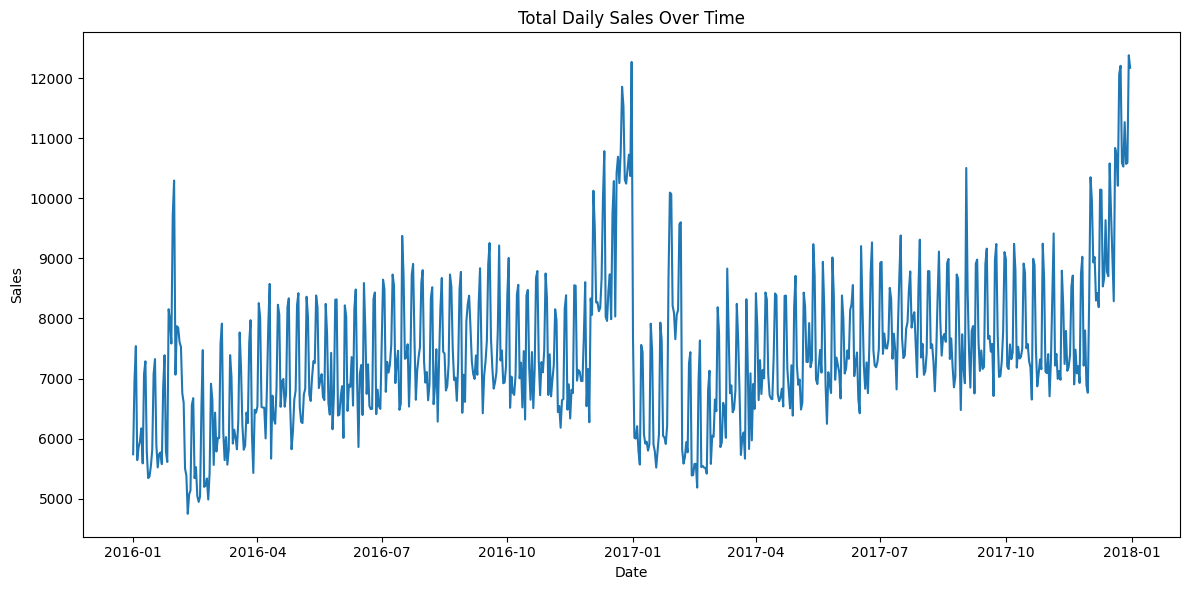

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(daily_sales["date"], daily_sales["sales"])
plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()

**Insights from the `daily_sales` line chart:**

- The `daily_sales` peaks around the **end of the year ⇒ *Year-end effect***
- In other times, the rate of `daily_sales` seems to be **stable**.

## Inspect weekly seasonality

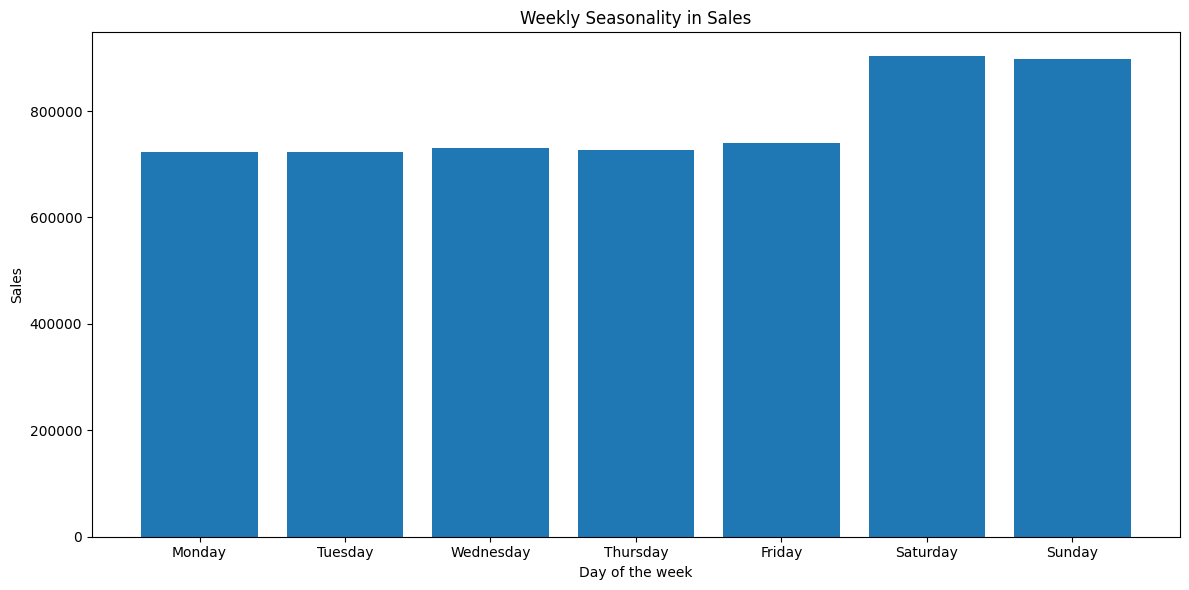

In [159]:
sales_df["day_of_week"]=sales_df["date"].dt.day_name()
weekly_sales=sales_df.groupby("day_of_week")["sales"].sum()
weekly_sales=weekly_sales.reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.figure(figsize=(12, 6))
plt.bar(weekly_sales.index, weekly_sales.values)
plt.title("Weekly Seasonality in Sales")
plt.xlabel("Day of the week")
plt.ylabel("Sales")
plt.tight_layout()

Insights from the bar chart showing **weekly seasonality in sales.**

- Mean of sales in weekdays seem to be **similar** but in weekend, sales **increase** dramatically
- It indicates that weekend demands were **stronger** than weekday.

## Inspect monthly seasonality

Text(0.5, 1.0, 'Monthly Seasonality in Sales')

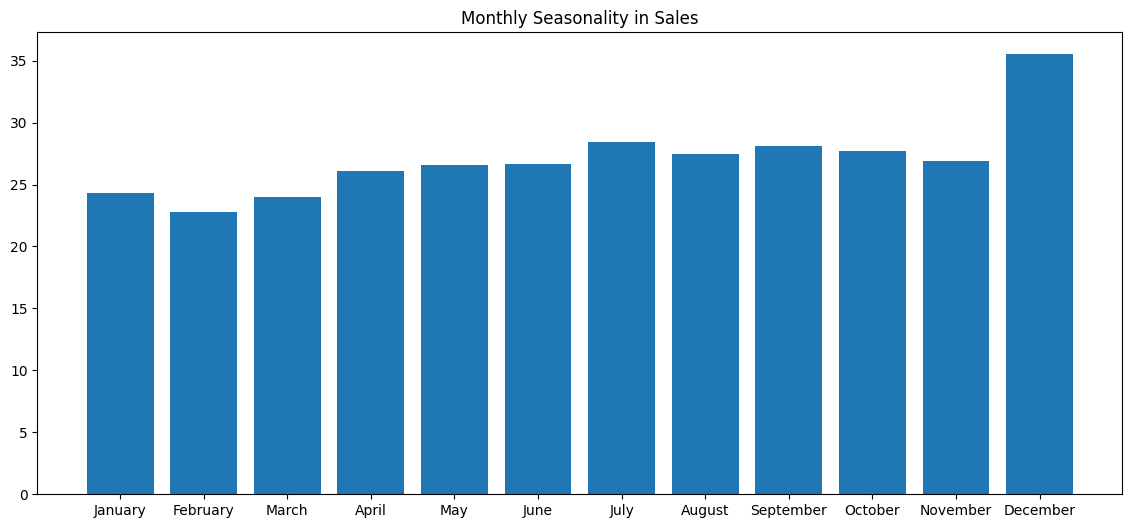

In [76]:
sales_df["month"]=sales_df["date"].dt.month_name()
monthly_sales=sales_df.groupby("month")["sales"].mean()
monthly_sales=monthly_sales.reindex(["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"])

plt.figure(figsize=(14, 6))
plt.bar(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Seasonality in Sales")       

Insights from the bar chart showing **monthly seasonality in sales:**

- The monthly pattern from **Jan to Nov** appeared to be **stable** and **equal**
- The sales in **Dec** shows the noticable **increase** compared to other month

## Inspect year-end/holiday peak sales

In [158]:
peak_days=pd.DataFrame(sales_df.groupby("date")["sales"].sum().sort_values(ascending=False).head(30)).reset_index()
peak_days.columns=["date", "sales"]

In [ ]:
peak_days["date"]=pd.to_datetime(peak_days["date"])
late_Dec_condition=(peak_days["date"].dt.month_name()=="December")&(peak_days["date"].dt.day>=20)
peak_days.loc[late_Dec_condition]

**Insights:** The majority of spike dates concentrate on **late December** from **20-31/12**

## Rolling trend and volatility

### Rolling trend

In [170]:
daily_sales = sales_df.groupby("date")["sales"].sum()

daily_sales.index = pd.to_datetime(daily_sales.index)
daily_sales = daily_sales.sort_index()

daily_sales.head()

date
2016-01-01    5738.422967
2016-01-02    6965.268902
2016-01-03    7539.422967
2016-01-04    5641.000000
2016-01-05    5850.422967
Name: sales, dtype: float64

In [171]:
rolling_mean_7 = daily_sales.rolling(window=7).mean()
rolling_mean_30 = daily_sales.rolling(window=30).mean()

rolling_std_7 = daily_sales.rolling(window=7).std()
rolling_std_30 = daily_sales.rolling(window=30).std()

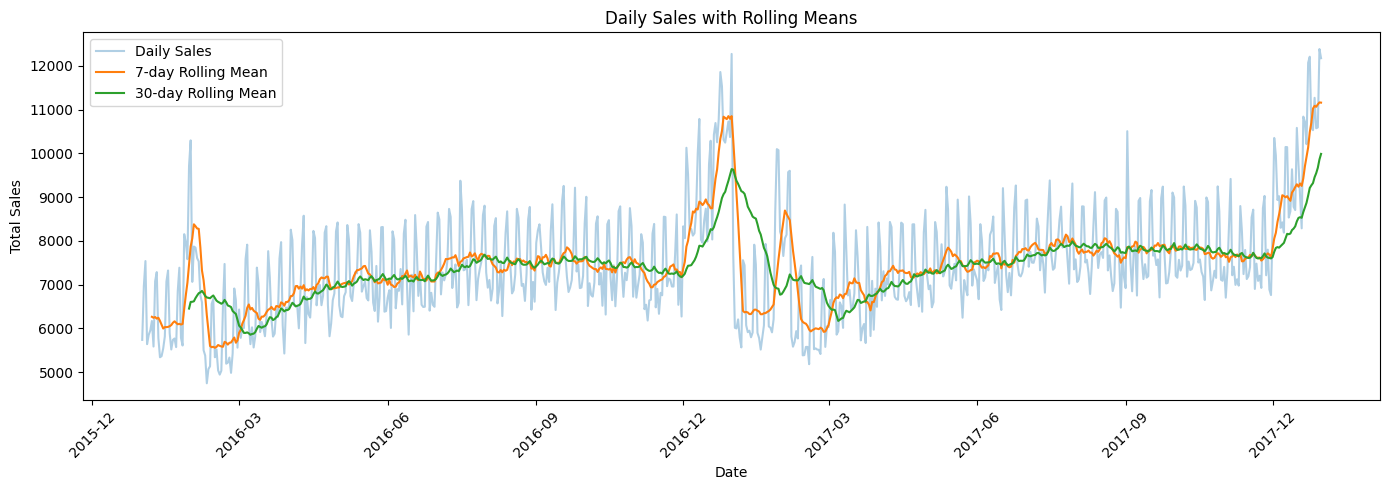

In [172]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    alpha=0.35,
    label="Daily Sales"
)

plt.plot(
    rolling_mean_7.index,
    rolling_mean_7.values,
    label="7-day Rolling Mean"
)

plt.plot(
    rolling_mean_30.index,
    rolling_mean_30.values,
    label="30-day Rolling Mean"
)

plt.title("Daily Sales with Rolling Means")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The `7-day` and `30-day` rolling means confirm a strong year-end increase in sales 

⇒ The smoothed trend rises sharply around late December, supporting the previous monthly seasonality and peak-date analysis.

### Volatility

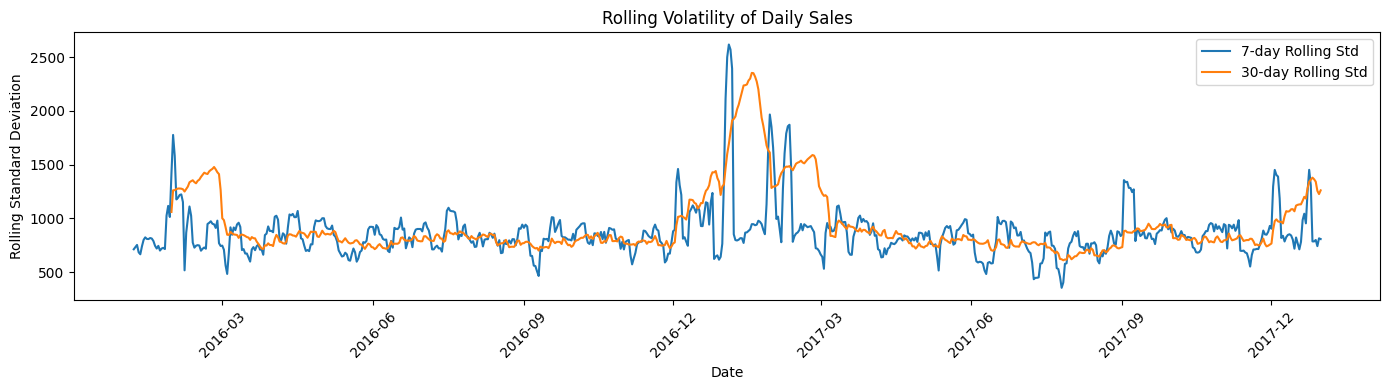

In [173]:
plt.figure(figsize=(14, 4))

plt.plot(
    rolling_std_7.index,
    rolling_std_7.values,
    label="7-day Rolling Std"
)

plt.plot(
    rolling_std_30.index,
    rolling_std_30.values,
    label="30-day Rolling Std"
)

plt.title("Rolling Volatility of Daily Sales")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

The rolling statistics confirm the year-end pattern observed earlier. Sales rise sharply around late December, and volatility also increases during this period.

⇒ Therefore, year-end demand is not only higher but also more unstable, which is important for forecasting.